# Final Test Evaluation of `F_final_fcos_tuned`

This notebook freezes and reports the final test evaluation for the selected FCOS detector. Its boundary is deliberately narrow:

$$
\text{frozen final model}
\rightarrow \text{verified best checkpoint}
\rightarrow \text{test inference}
\rightarrow \text{final metrics and CPU predictions}
\rightarrow \text{post-hoc error analysis in notebook 08}.
$$

No training, checkpoint selection, hyperparameter refinement, or threshold search belongs here. Existing evaluation artifacts are loaded by default so restarting the notebook does not silently repeat GPU inference or replace the historical result.

## 1. Objective and frozen evaluation protocol

All architecture, optimizer, learning-rate, scheduler, regularization, augmentation, input-resolution, backbone, and fine-tuning decisions were completed with the train and validation subsets before this evaluation. Notebook 06 selected `F_final_fcos_tuned`; notebook 07 evaluates that fixed decision.

Earlier dataset preparation and EDA inspected aggregate test-set structure. Consequently, the test subset is not described as literally untouched. The narrower and defensible claim is that **test predictive performance was not used for model fitting, architecture selection, refinement, checkpoint selection, or threshold optimization**.

“One-time test evaluation” is a decision rule, not a ban on deterministic re-execution: these results must not trigger another model-development decision in the same cycle. They form the final held-out test estimate under the frozen protocol, not a claim of a perfectly unbiased estimate.

The primary metric is COCO $\mathrm{mAP}@0.5{:}0.95$. A fixed operating point of confidence $0.50$ and matching IoU $0.50$ was declared before examining test predictive performance and is retained for practical diagnostics only.

In [1]:
CONFIDENCE_THRESHOLD = 0.50
IOU_MATCH_THRESHOLD = 0.50
EXPECTED_EXPERIMENT_ID = "F_final_fcos_tuned"
EXPECTED_MODEL_FAMILY = "fcos"
EXPECTED_BACKBONE = "resnet50"
EXPECTED_IMAGE_SIZE = 768
EXPECTED_FOREGROUND_CLASSES = 4
EXPECTED_CHECKPOINT_SHA256 = "ec4ee94b2bf7afcb77873fe4d26915bec2c7af71f09cd68353beb65561ca783d"

# Safe restart defaults: consume the frozen artifacts instead of repeating evaluation.
RUN_FINAL_TEST_INFERENCE = False
RUN_INFERENCE_BENCHMARK = False

EVALUATION_PROTOCOL = {
    "primary_metric": "mAP@0.5:0.95",
    "operating_point_confidence": CONFIDENCE_THRESHOLD,
    "operating_point_iou": IOU_MATCH_THRESHOLD,
    "threshold_policy": "fixed before test evaluation; never optimized on test",
    "selection_policy": "evaluate only the model selected by notebook 06",
    "test_usage_policy": "results do not trigger model changes in this development cycle",
}
EVALUATION_PROTOCOL

{'primary_metric': 'mAP@0.5:0.95',
 'operating_point_confidence': 0.5,
 'operating_point_iou': 0.5,
 'threshold_policy': 'fixed before test evaluation; never optimized on test',
 'selection_policy': 'evaluate only the model selected by notebook 06',
 'test_usage_policy': 'results do not trigger model changes in this development cycle'}

## 2. Selected-model provenance

The evaluation target must resolve to the exact `best.pth` produced by `F_final_fcos_tuned`. Generic pretrained FCOS weights are not an acceptable fallback. Metadata, experiment identity, architecture, backbone, input size, class count, checkpoint payload, strict `state_dict` compatibility, and checkpoint fingerprint are checked before inference.

The stored selection status `provisional_until_test_evaluation` records the historical handoff from notebook 06. It does not authorize reselection in this notebook.

In [3]:
from __future__ import annotations

from dataclasses import dataclass
from functools import partial
from pathlib import Path
import hashlib
import json
import platform
import random
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torchvision
from IPython.display import display
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import functional as TF
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
sns.set_theme(style="whitegrid", context="notebook")
REPORT_BLUE = "#3B6EA8"
REPORT_ORANGE = "#E17C36"
REPORT_RED = "#C44E52"
REPORT_GREEN = "#4C956C"


def print_section(title, rows=None):
    print()
    print("=" * 72)
    print(title)
    print("=" * 72)
    if rows:
        width = max(len(str(label)) for label, _ in rows)
        for label, value in rows:
            print(f"{label:<{width}} : {value}")


print_section("RUNTIME ENVIRONMENT", [
    ("Python", sys.version.split()[0]),
    ("PyTorch", torch.__version__),
    ("Torchvision", torchvision.__version__),
    ("CUDA runtime", torch.version.cuda or "not available"),
    ("Device", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"),
])


RUNTIME ENVIRONMENT
Python       : 3.13.5
PyTorch      : 2.11.0+cu128
Torchvision  : 0.26.0+cu128
CUDA runtime : 12.8
Device       : NVIDIA GeForce RTX 3050 Laptop GPU


In [4]:
@dataclass(frozen=True)
class Paths:
    root: Path
    canonical: Path
    selected_metadata: Path
    evaluation: Path


def resolve_paths():
    root = Path.cwd().resolve()
    if not (root / "data" / "processed" / "dentex_diagnosis").is_dir():
        root = root.parent
    return Paths(
        root=root,
        canonical=root / "data" / "processed" / "dentex_diagnosis",
        selected_metadata=root / "artifacts" / "refinement" / "fcos" / "selected_final_model.json",
        evaluation=root / "artifacts" / "final_evaluation",
    )


PATHS = resolve_paths()
TEST_JSON = PATHS.canonical / "annotations" / "test.json"
TEST_IMAGES = PATHS.canonical / "images" / "test"
CLASS_NAMES = {0: "Impacted", 1: "Caries", 2: "Periapical Lesion", 3: "Deep Caries"}

for required_path in (PATHS.selected_metadata, TEST_JSON, TEST_IMAGES, PATHS.evaluation):
    if not required_path.exists():
        raise FileNotFoundError(required_path)

In [5]:
def file_sha256(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for chunk in iter(lambda: stream.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def load_selected_model_metadata(path=PATHS.selected_metadata):
    metadata = json.loads(path.read_text(encoding="utf-8"))
    required = {
        "selected_final_experiment_id", "architecture", "backbone", "best_checkpoint",
        "best_epoch", "validation_mAP50_95", "validation_mAP50", "recall_mAR100",
        "image_size", "final_config", "status",
    }
    missing = required - metadata.keys()
    if missing:
        raise RuntimeError(f"Selected-model metadata lacks: {sorted(missing)}")
    if metadata["selected_final_experiment_id"] != EXPECTED_EXPERIMENT_ID:
        raise RuntimeError("Unexpected selected experiment.")
    if "FCOS" not in metadata["architecture"].upper():
        raise RuntimeError("Selected architecture is not FCOS.")
    if metadata["backbone"] != EXPECTED_BACKBONE or int(metadata["image_size"]) != EXPECTED_IMAGE_SIZE:
        raise RuntimeError("Selected-model configuration disagrees with the frozen protocol.")
    if metadata["final_config"]["experiment_id"] != EXPECTED_EXPERIMENT_ID:
        raise RuntimeError("Nested final configuration has a different experiment identity.")

    checkpoint_path = Path(metadata["best_checkpoint"])
    if not checkpoint_path.is_file() or checkpoint_path.name != "best.pth":
        raise FileNotFoundError(f"The exact persisted best.pth is required: {checkpoint_path}")
    checkpoint_sha256 = file_sha256(checkpoint_path)
    if checkpoint_sha256 != EXPECTED_CHECKPOINT_SHA256:
        raise RuntimeError("Checkpoint SHA-256 differs from the frozen evaluation identity.")
    return metadata, checkpoint_path, checkpoint_sha256


SELECTED, CHECKPOINT_PATH, CHECKPOINT_SHA256 = load_selected_model_metadata()
display(pd.Series({
    "experiment_id": SELECTED["selected_final_experiment_id"],
    "architecture": SELECTED["architecture"],
    "backbone": SELECTED["backbone"],
    "image_size": SELECTED["image_size"],
    "best_epoch": SELECTED["best_epoch"],
    "checkpoint": str(CHECKPOINT_PATH),
    "checkpoint_sha256": CHECKPOINT_SHA256,
    "selection_status": SELECTED["status"],
}, name="value").to_frame())

,value
experiment_id,F_final_fcos_tuned
architecture,FCOS ResNet50 FPN
backbone,resnet50
image_size,768
best_epoch,17
checkpoint,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
checkpoint_sha256,ec4ee94b2bf7afcb77873fe4d26915bec2c7af71f09cd6...
selection_status,provisional_until_test_evaluation


## 3. Test dataset loading and integrity checks

The test split is read from the canonical processed DENTEX diagnosis dataset without rewriting annotations, filtering difficult cases, or changing membership. Each COCO annotation is converted from $[x, y, w, h]$ to detector coordinates $[x_1, y_1, x_2, y_2]$, where $x_2=x+w$ and $y_2=y+h$.

The audit verifies unique image IDs and filenames, referential integrity between annotations and images/categories, existing image files, four canonical classes, and positive boxes contained within declared image dimensions. These are structural checks; they do not inspect predictive performance or modify the split.

In [6]:
def load_coco(path):
    with Path(path).open(encoding="utf-8") as stream:
        return json.load(stream)


class TestDataset(Dataset):
    def __init__(self, annotation_file, image_dir):
        self.coco = load_coco(annotation_file)
        self.image_dir = Path(image_dir)
        self.images = sorted(self.coco["images"], key=lambda item: item["id"])
        category_ids = sorted(category["id"] for category in self.coco["categories"])
        self.category_to_label = {category_id: index + 1 for index, category_id in enumerate(category_ids)}
        self.annotations_by_image = {image["id"]: [] for image in self.images}
        for annotation in self.coco["annotations"]:
            self.annotations_by_image[annotation["image_id"]].append(annotation)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        info = self.images[index]
        image = Image.open(self.image_dir / info["file_name"]).convert("RGB")
        boxes, labels = [], []
        for annotation in self.annotations_by_image[info["id"]]:
            x, y, width, height = annotation["bbox"]
            boxes.append([x, y, x + width, y + height])
            labels.append(self.category_to_label[annotation["category_id"]])
        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32).reshape(-1, 4),
            "labels": torch.tensor(labels, dtype=torch.int64),
            "image_id": torch.tensor(info["id"], dtype=torch.int64),
        }
        return TF.to_tensor(image), target, info["file_name"]


def detection_collate(items):
    return tuple(zip(*items))


TEST_DATASET = TestDataset(TEST_JSON, TEST_IMAGES)
TEST_LOADER = DataLoader(TEST_DATASET, batch_size=1, shuffle=False, num_workers=0, collate_fn=detection_collate)

In [7]:
def audit_test_annotations(dataset):
    images = dataset.coco["images"]
    annotations = dataset.coco["annotations"]
    categories = dataset.coco["categories"]
    image_ids = [item["id"] for item in images]
    file_names = [item["file_name"] for item in images]
    category_ids = {item["id"] for item in categories}
    image_info = {item["id"]: item for item in images}

    if len(image_ids) != len(set(image_ids)) or len(file_names) != len(set(file_names)):
        raise RuntimeError("Test image IDs and filenames must be unique.")
    if len(categories) != EXPECTED_FOREGROUND_CLASSES:
        raise RuntimeError("Unexpected number of test categories.")
    missing_files = [name for name in file_names if not (dataset.image_dir / name).is_file()]
    if missing_files:
        raise FileNotFoundError(f"Missing test images: {missing_files[:5]}")

    class_counts = {name: 0 for name in CLASS_NAMES.values()}
    for annotation in annotations:
        if annotation["image_id"] not in image_info or annotation["category_id"] not in category_ids:
            raise RuntimeError("Broken annotation referential integrity.")
        x, y, width, height = annotation["bbox"]
        info = image_info[annotation["image_id"]]
        if width <= 0 or height <= 0 or x < 0 or y < 0 or x + width > info["width"] or y + height > info["height"]:
            raise RuntimeError(f"Invalid test box in annotation {annotation.get('id')}.")
        label = dataset.category_to_label[annotation["category_id"]] - 1
        class_counts[CLASS_NAMES[label]] += 1

    return pd.DataFrame([{"test_images": len(images), "total_boxes": len(annotations), **class_counts}])


TEST_AUDIT = audit_test_annotations(TEST_DATASET)
assert int(TEST_AUDIT.loc[0, "test_images"]) == 106, "Historical final evaluation expects 106 test images."
print_section("TEST DATASET INTEGRITY", [
    ("Images", int(TEST_AUDIT.loc[0, "test_images"])),
    ("Ground-truth boxes", int(TEST_AUDIT.loc[0, "total_boxes"])),
    ("Classes", len(CLASS_NAMES)),
    ("Image IDs", "unique"),
    ("Paths / labels / boxes", "valid"),
    ("Integrity status", "PASSED"),
])
display(TEST_AUDIT.set_index(pd.Index(["Count"])))


TEST DATASET INTEGRITY
Images                 : 106
Ground-truth boxes     : 539
Classes                : 4
Image IDs              : unique
Paths / labels / boxes : valid
Integrity status       : PASSED


,test_images,total_boxes,Impacted,Caries,Periapical Lesion,Deep Caries
Count,106,539,96,333,26,84


**Observation.** The frozen test split contains 106 unique images and 539 valid boxes: 96 Impacted, 333 Caries, 26 Periapical Lesion, and 84 Deep Caries annotations. The marked class imbalance is context for interpretation, not a reason to alter the test set or reduce the weakest class to prevalence alone.

## 4. Final FCOS reconstruction and checkpoint verification

The detector is reconstructed as FCOS with a ResNet50-FPN backbone, fixed $768	imes768$ transform, and four foreground classes plus the torchvision background convention. Both generic detector weights and generic backbone weights are disabled. The checkpoint must declare the same experiment and model family, then load with strict key matching.

In [8]:
def build_final_model(metadata):
    from torchvision.models.detection import fcos_resnet50_fpn
    from torchvision.models.detection.fcos import FCOSClassificationHead

    config = metadata["final_config"]
    model = fcos_resnet50_fpn(
        weights=None,
        weights_backbone=None,
        min_size=int(config["image_size"]),
        max_size=int(config["image_size"]),
    )
    model.head.classification_head = FCOSClassificationHead(
        model.backbone.out_channels,
        model.anchor_generator.num_anchors_per_location()[0],
        EXPECTED_FOREGROUND_CLASSES + 1,
        norm_layer=partial(nn.GroupNorm, 32),
    )
    return model


def load_final_checkpoint(model, checkpoint_path, device):
    payload = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    if payload.get("experiment_id") != EXPECTED_EXPERIMENT_ID:
        raise RuntimeError("Checkpoint experiment identity mismatch.")
    if payload.get("model_family") != EXPECTED_MODEL_FAMILY:
        raise RuntimeError("Checkpoint model-family mismatch.")
    incompatible = model.load_state_dict(payload["model_state_dict"], strict=True)
    if incompatible.missing_keys or incompatible.unexpected_keys:
        raise RuntimeError(f"Checkpoint/model mismatch: {incompatible}")
    model.to(device).eval()
    audit = {
        "checkpoint_sha256": CHECKPOINT_SHA256,
        "missing_keys": incompatible.missing_keys,
        "unexpected_keys": incompatible.unexpected_keys,
        "parameter_count": sum(parameter.numel() for parameter in model.parameters()),
        "persisted_checkpoint_size_mb": checkpoint_path.stat().st_size / 1e6,
        "device": str(device),
    }
    return payload, audit


DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
MODEL = build_final_model(SELECTED)
CHECKPOINT, MODEL_AUDIT = load_final_checkpoint(MODEL, CHECKPOINT_PATH, DEVICE)
print_section("CHECKPOINT COMPATIBILITY", [
    ("Strict state_dict load", "PASSED"),
    ("Missing keys", len(MODEL_AUDIT["missing_keys"])),
    ("Unexpected keys", len(MODEL_AUDIT["unexpected_keys"])),
    ("Parameters", f'{MODEL_AUDIT["parameter_count"]:,}'),
    ("Checkpoint size", f'{MODEL_AUDIT["persisted_checkpoint_size_mb"]:.1f} MB'),
    ("Device", MODEL_AUDIT["device"]),
])


CHECKPOINT COMPATIBILITY
Strict state_dict load : PASSED
Missing keys           : 0
Unexpected keys        : 0
Parameters             : 32,124,490
Checkpoint size        : 383.7 MB
Device                 : cuda:0


**Observation.** Strict loading produced no missing or unexpected keys. The evaluated checkpoint has SHA-256 `ec4ee94b2bf7afcb77873fe4d26915bec2c7af71f09cd68353beb65561ca783d`, and the reconstructed model contains 32,124,490 parameters. The 383.7 MB figure is the persisted checkpoint-file size, not the size of a future ONNX or deployed service representation.

## 5. Test inference

Inference uses `model.eval()` and `torch.inference_mode()` only. There is no optimizer, scheduler, gradient update, or alternate-checkpoint branch. Every prediction is detached and moved to CPU before persistence. Each record retains image identity, dimensions, ground truth, and prediction `boxes`, `labels`, and `scores`, allowing notebook 08 to work without loading the model or rerunning GPU inference.

By default the cell below validates and loads the canonical historical `test_predictions.pt`. Setting `RUN_FINAL_TEST_INFERENCE=True` explicitly regenerates deterministic predictions from the same frozen checkpoint; it does not change the development decision.

In [9]:
PREDICTIONS_PATH = PATHS.evaluation / "test_predictions.pt"


def collect_predictions(model, loader, device):
    records = []
    model.eval()
    with torch.inference_mode():
        for images, targets, names in tqdm(loader, desc="Final test inference"):
            output = model([images[0].to(device)])[0]
            records.append({
                "image_id": int(targets[0]["image_id"]),
                "file_name": names[0],
                "prediction": {key: value.detach().cpu() for key, value in output.items() if key in {"boxes", "scores", "labels"}},
                "target": {key: value.detach().cpu() for key, value in targets[0].items()},
                "original_width": int(images[0].shape[2]),
                "original_height": int(images[0].shape[1]),
            })
    return records


if RUN_FINAL_TEST_INFERENCE:
    TEST_RECORDS = collect_predictions(MODEL, TEST_LOADER, DEVICE)
    torch.save(TEST_RECORDS, PREDICTIONS_PATH)
else:
    if not PREDICTIONS_PATH.is_file():
        raise FileNotFoundError("Canonical predictions are absent; set RUN_FINAL_TEST_INFERENCE=True to generate them.")
    TEST_RECORDS = torch.load(PREDICTIONS_PATH, map_location="cpu", weights_only=False)

expected_ids = {item["id"] for item in TEST_DATASET.images}
record_ids = [record["image_id"] for record in TEST_RECORDS]
if len(record_ids) != len(TEST_DATASET) or set(record_ids) != expected_ids or len(record_ids) != len(set(record_ids)):
    raise RuntimeError("Persisted predictions do not match the frozen test split.")
prediction_mode = "regenerated from frozen checkpoint" if RUN_FINAL_TEST_INFERENCE else "loaded from persisted artifact"
print_section("FINAL TEST PREDICTIONS", [
    ("Mode", prediction_mode),
    ("Records", len(TEST_RECORDS)),
    ("Storage", "CPU tensors"),
    ("Artifact", PREDICTIONS_PATH),
    ("Split match", "PASSED"),
])


FINAL TEST PREDICTIONS
Mode        : loaded from persisted artifact
Records     : 106
Storage     : CPU tensors
Artifact    : C:\Users\Eclipse\PycharmProjects\Dental-Xray-Pathology-Detection\artifacts\final_evaluation\test_predictions.pt
Split match : PASSED


## 6. COCO-style test metrics

COCO evaluation measures detector ranking and localization across confidence levels and multiple IoU thresholds. The final test result is:

| Metric | Test |
|---|---:|
| $\mathrm{mAP}@0.5{:}0.95$ | 0.2664 |
| $\mathrm{mAP}@0.5$ | 0.4407 |
| $\mathrm{mAR}@100$ | 0.5170 |
| Images | 106 |

The primary result is $\mathrm{mAP}@0.5{:}0.95=0.2664$. The higher $\mathrm{mAP}@0.5=0.4407$ is expected: the former averages AP across increasingly strict IoU thresholds and therefore penalizes imprecise localization more strongly. $\mathrm{mAR}@100$ is a COCO mean average recall quantity and is not interchangeable with threshold-specific Recall.

In [10]:
def evaluate_coco_metrics(records):
    predictions = [record["prediction"] for record in records]
    targets = [{key: value for key, value in record["target"].items() if key in {"boxes", "labels"}} for record in records]
    coco = MeanAveragePrecision(box_format="xyxy", iou_type="bbox", class_metrics=True)
    ap50 = MeanAveragePrecision(box_format="xyxy", iou_type="bbox", iou_thresholds=[0.5], class_metrics=True)
    coco.update(predictions, targets)
    ap50.update(predictions, targets)
    overall, at_50 = coco.compute(), ap50.compute()
    rows = []
    for index, label in enumerate(overall["classes"].tolist()):
        rows.append({
            "class_id": int(label) - 1,
            "class_name": CLASS_NAMES[int(label) - 1],
            "AP50_95": float(overall["map_per_class"][index]),
            "AP50": float(at_50["map_per_class"][index]),
            "mAR100": float(overall["mar_100_per_class"][index]),
        })
    metrics = {
        "mAP50_95": float(overall["map"]),
        "mAP50": float(overall["map_50"]),
        "mAR100": float(overall["mar_100"]),
        "images": len(records),
    }
    return metrics, pd.DataFrame(rows).sort_values("class_id")


TEST_METRICS, PER_CLASS_TEST = evaluate_coco_metrics(TEST_RECORDS)
PERSISTED_TEST_METRICS = json.loads((PATHS.evaluation / "test_metrics.json").read_text(encoding="utf-8"))
for metric in ("mAP50_95", "mAP50", "mAR100"):
    if not np.isclose(TEST_METRICS[metric], PERSISTED_TEST_METRICS[metric], atol=1e-8):
        raise RuntimeError(f"Recomputed {metric} differs from the frozen artifact.")
metric_summary = pd.DataFrame({
    "Metric": ["mAP@0.5:0.95", "mAP@0.5", "mAR@100", "Test images"],
    "Value": [TEST_METRICS["mAP50_95"], TEST_METRICS["mAP50"], TEST_METRICS["mAR100"], TEST_METRICS["images"]],
})
print_section("CANONICAL COCO-STYLE TEST METRICS", [
    ("Artifact verification", "PASSED"),
    ("Primary metric", f'{TEST_METRICS["mAP50_95"]:.4f} mAP@0.5:0.95'),
])
display(metric_summary.style.format({"Value": lambda value: f"{value:.4f}" if isinstance(value, float) else f"{int(value)}"}))


CANONICAL COCO-STYLE TEST METRICS
Artifact verification : PASSED
Primary metric        : 0.2664 mAP@0.5:0.95


,Metric,Value
0,mAP@0.5:0.95,0.2664
1,mAP@0.5,0.4407
2,mAR@100,0.5170
3,Test images,106.0000


## 7. Per-class test performance

| Class | AP@0.5:0.95 | AP@0.5 | mAR@100 |
|---|---:|---:|---:|
| Impacted | 0.4699 | 0.8307 | 0.6052 |
| Caries | 0.2378 | 0.3668 | 0.6105 |
| Periapical Lesion | 0.1336 | 0.2127 | 0.2962 |
| Deep Caries | 0.2244 | 0.3527 | 0.5560 |

Impacted has the strongest AP, including AP@0.5 of 0.8307. Caries has the highest mAR@100 but materially lower AP, which indicates that recall capacity does not by itself establish reliable classification and localization. Periapical Lesion remains weakest on both AP@0.5:0.95 and mAR@100, consistent with earlier validation evidence. Rarity is relevant, but the available evidence does not isolate it from morphology, lesion subtlety, annotation uncertainty, or localization difficulty.

,class_id,class_name,AP50_95,AP50,mAR100
0,0,Impacted,0.4699,0.8307,0.6052
1,1,Caries,0.2378,0.3668,0.6105
2,2,Periapical Lesion,0.1336,0.2127,0.2962
3,3,Deep Caries,0.2244,0.3527,0.5560


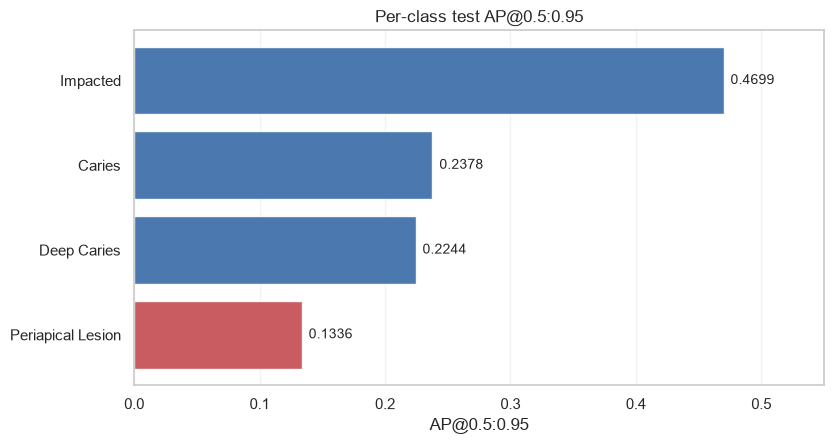

In [11]:
persisted_per_class = pd.read_csv(PATHS.evaluation / "per_class_test_metrics.csv")
pd.testing.assert_frame_equal(
    PER_CLASS_TEST.reset_index(drop=True),
    persisted_per_class.reset_index(drop=True),
    check_exact=False,
    atol=1e-8,
)
display(PER_CLASS_TEST.style.format({"AP50_95": "{:.4f}", "AP50": "{:.4f}", "mAR100": "{:.4f}"}))

plot_data = PER_CLASS_TEST.sort_values("AP50_95", ascending=True).copy()
weakest_class = plot_data.iloc[0]["class_name"]
colors = [REPORT_RED if name == weakest_class else REPORT_BLUE for name in plot_data["class_name"]]

fig, ax = plt.subplots(figsize=(8.5, 4.6))
bars = ax.barh(plot_data["class_name"], plot_data["AP50_95"], color=colors, alpha=0.92)
ax.bar_label(bars, labels=[f"{value:.4f}" for value in plot_data["AP50_95"]], padding=5, fontsize=10)
ax.set(
    title="Per-class test AP@0.5:0.95",
    xlabel="AP@0.5:0.95",
    ylabel="",
    xlim=(0, max(0.55, plot_data["AP50_95"].max() + 0.08)),
)
ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

## 8. Fixed operating-point metrics

COCO metrics aggregate detector behavior across broader ranking and localization conditions. The fixed operating point instead asks: how does the frozen detector behave when predictions require confidence $\geq0.50$ and a same-class, one-to-one match requires IoU $\geq0.50$?

$$
\mathrm{Precision}=\frac{TP}{TP+FP},\qquad
\mathrm{Recall}=\frac{TP}{TP+FN},\qquad
F_1=2\frac{\mathrm{Precision}\cdot\mathrm{Recall}}{\mathrm{Precision}+\mathrm{Recall}}.
$$

The frozen totals are $TP=230$, $FP=181$, and $FN=309$, yielding Precision $0.5596$, Recall $0.4267$, and $F_1=0.4842$. The 309 missed ground-truth objects show that a substantial fraction of lesions does not survive the fixed confidence/matching requirements. These values must not be described as COCO mAP or mAR, and the threshold is not retuned after observing them.


FIXED OPERATING POINT
Confidence threshold : 0.50
IoU threshold        : 0.50
Accepted detections  : 411
Ground-truth objects : 539


,Metric,Value
0,Precision,0.5596
1,Recall,0.4267
2,F1,0.4842
3,TP,230.0000
4,FP,181.0000
5,FN,309.0000


,class_id,class_name,TP,FP,FN,Precision,Recall,F1
0,0,Impacted,74,9,22,0.8916,0.7708,0.8268
1,1,Caries,130,151,203,0.4626,0.3904,0.4235
2,2,Periapical Lesion,2,0,24,1.0000,0.0769,0.1429
3,3,Deep Caries,24,21,60,0.5333,0.2857,0.3721


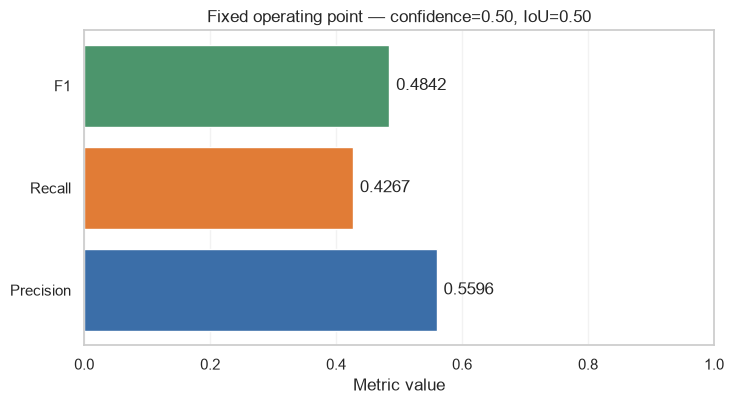

In [12]:
OPERATING_POINT = json.loads((PATHS.evaluation / "operating_point_metrics.json").read_text(encoding="utf-8"))
OPERATING_PER_CLASS = pd.DataFrame(OPERATING_POINT["per_class"])

operating_summary = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1", "TP", "FP", "FN"],
    "Value": [OPERATING_POINT[key] for key in ["Precision", "Recall", "F1", "TP", "FP", "FN"]],
})
print_section("FIXED OPERATING POINT", [
    ("Confidence threshold", f'{OPERATING_POINT["confidence_threshold"]:.2f}'),
    ("IoU threshold", f'{OPERATING_POINT["iou_match_threshold"]:.2f}'),
    ("Accepted detections", OPERATING_POINT["TP"] + OPERATING_POINT["FP"]),
    ("Ground-truth objects", OPERATING_POINT["TP"] + OPERATING_POINT["FN"]),
])
display(operating_summary.style.format({"Value": lambda value: f"{value:.4f}" if isinstance(value, float) else f"{int(value)}"}))
display(OPERATING_PER_CLASS.style.format({"Precision": "{:.4f}", "Recall": "{:.4f}", "F1": "{:.4f}"}))

quality_metrics = pd.Series({name: OPERATING_POINT[name] for name in ["Precision", "Recall", "F1"]})
fig, ax = plt.subplots(figsize=(7.5, 4.2))
bars = ax.barh(quality_metrics.index, quality_metrics.values, color=[REPORT_BLUE, REPORT_ORANGE, REPORT_GREEN])
ax.bar_label(bars, labels=[f"{value:.4f}" for value in quality_metrics.values], padding=5)
ax.set(
    title="Fixed operating point — confidence=0.50, IoU=0.50",
    xlabel="Metric value",
    ylabel="",
    xlim=(0, 1.0),
)
ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

The Periapical Lesion row requires careful interpretation: Precision is 1.0 only because two accepted predictions were correct and no accepted false positives occurred. Recall is 0.0769, with 24 of 26 lesions missed. It is therefore a severe low-recall result, not evidence of excellent class performance.

## 9. Validation vs test comparison

Model selection used validation evidence; the test comparison is descriptive and cannot support a significance claim from one split.

| Metric | Validation | Test | Test − Validation |
|---|---:|---:|---:|
| mAP@0.5:0.95 | 0.2813 | 0.2664 | −0.0149 |
| mAP@0.5 | 0.4957 | 0.4407 | −0.0550 |
| mAR@100 | 0.5056 | 0.5170 | +0.0114 |

The primary metric shows a modest validation-to-test decrease rather than a catastrophic generalization gap. AP@0.5 falls more, while mAR@100 increases slightly. This does not prove absence of overfitting or equality of the validation and test distributions.

The final experiment's historical `metrics.json` contains per-class validation diagnostics, but the training pipeline does not prove that those per-class values were captured from the exact globally best checkpoint rather than the current/final epoch. They are therefore excluded from checkpoint-perfect per-class validation–test claims. The globally persisted best-checkpoint metrics used for selection remain the comparison source above.

,Metric,Validation,Test,Absolute delta
0,mAP50_95,0.2813,0.2664,-0.0149
1,mAP50,0.4957,0.4407,-0.0550
2,mAR100,0.5056,0.5170,+0.0114


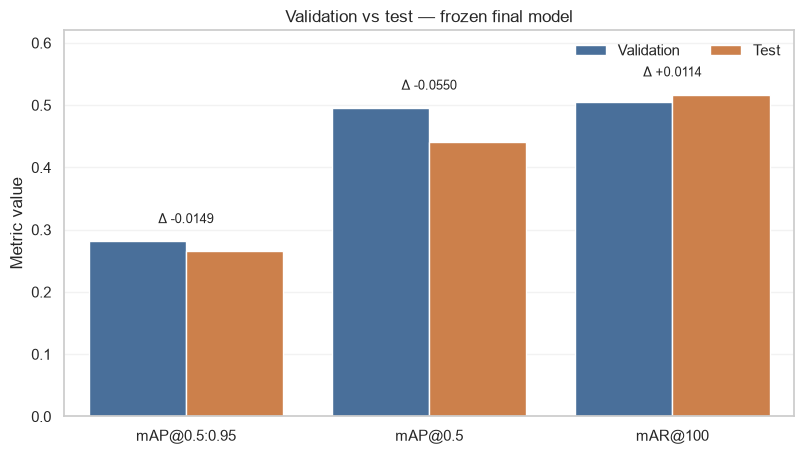

In [13]:
VALIDATION_METRICS = {
    "mAP50_95": SELECTED["validation_mAP50_95"],
    "mAP50": SELECTED["validation_mAP50"],
    "mAR100": SELECTED["recall_mAR100"],
}
VALIDATION_VS_TEST = pd.DataFrame([
    {
        "Metric": metric,
        "Validation": value,
        "Test": TEST_METRICS[metric],
        "Absolute delta": TEST_METRICS[metric] - value,
    }
    for metric, value in VALIDATION_METRICS.items()
])
persisted_comparison = pd.read_csv(PATHS.evaluation / "validation_vs_test.csv")
pd.testing.assert_frame_equal(VALIDATION_VS_TEST, persisted_comparison, check_exact=False, atol=1e-8)
display(VALIDATION_VS_TEST.style.format({"Validation": "{:.4f}", "Test": "{:.4f}", "Absolute delta": "{:+.4f}"}))

label_map = {"mAP50_95": "mAP@0.5:0.95", "mAP50": "mAP@0.5", "mAR100": "mAR@100"}
plot_frame = VALIDATION_VS_TEST.copy()
plot_frame["Metric"] = plot_frame["Metric"].map(label_map)
long_frame = plot_frame.melt(
    id_vars=["Metric", "Absolute delta"],
    value_vars=["Validation", "Test"],
    var_name="Subset",
    value_name="Value",
)
fig, ax = plt.subplots(figsize=(8.2, 4.7))
sns.barplot(data=long_frame, x="Metric", y="Value", hue="Subset", palette=[REPORT_BLUE, REPORT_ORANGE], ax=ax)
for index, row in plot_frame.reset_index(drop=True).iterrows():
    top = max(row["Validation"], row["Test"])
    ax.text(index, top + 0.025, f'Δ {row["Absolute delta"]:+.4f}', ha="center", va="bottom", fontsize=9)
ax.set(title="Validation vs test — frozen final model", xlabel="", ylabel="Metric value", ylim=(0, 0.62))
ax.legend(title="", frameon=False, ncol=2, loc="upper right")
ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

## 10. Inference benchmark

The historical benchmark used CUDA, batch size 1, five warm-up passes, explicit CUDA synchronization, and 30 timed test images. Images were loaded, converted to tensors, and moved to the device **before** timing. The result therefore measures model inference latency on preloaded/preprocessed tensors; it excludes disk I/O, image decoding, tensor preparation, API overhead, persistence, and response serialization.

Mean latency was 55.6 ms, median 54.9 ms, and P95 64.2 ms, corresponding to an approximate model-only throughput of 18.0 images/s on the recorded NVIDIA GeForce RTX 3050 Laptop GPU. Peak allocated GPU memory was about 1,639 MB. These values are hardware- and protocol-specific and are not end-to-end service latency.


INFERENCE BENCHMARK
Source          : persisted benchmark
Timing boundary : model inference on preloaded/preprocessed device tensors
Timed images    : 30
Warm-up images  : 5
Device          : cuda:0
Batch size      : 1


,Statistic,Value
0,Mean latency,55.6 ms
1,Median latency,54.9 ms
2,P95 latency,64.2 ms
3,Approx. FPS,18.0
4,Peak GPU memory,1639 MB


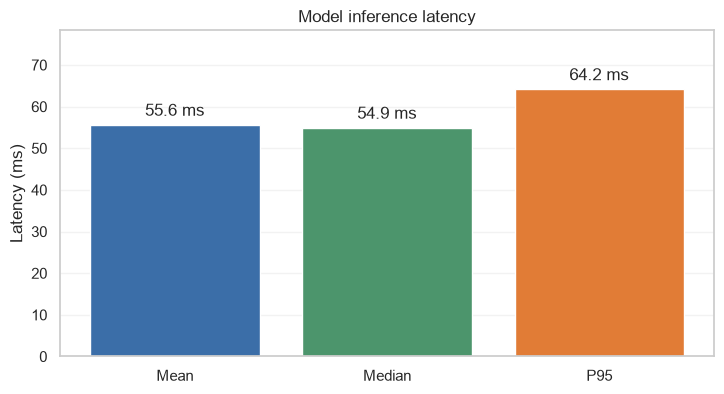

In [14]:
def benchmark_inference(model, dataset, device, count=30, warmup_count=5):
    images = [dataset[index][0].to(device) for index in range(min(count, len(dataset)))]
    model.eval()
    elapsed_ms = []
    with torch.inference_mode():
        for image in images[:warmup_count]:
            model([image])
        if device.type == "cuda":
            torch.cuda.synchronize()
            torch.cuda.reset_peak_memory_stats()
        for image in images:
            if device.type == "cuda":
                torch.cuda.synchronize()
            started = time.perf_counter()
            model([image])
            if device.type == "cuda":
                torch.cuda.synchronize()
            elapsed_ms.append((time.perf_counter() - started) * 1000)
    return {
        "mean_latency_ms": float(np.mean(elapsed_ms)),
        "median_latency_ms": float(np.median(elapsed_ms)),
        "p95_latency_ms": float(np.percentile(elapsed_ms, 95)),
        "approximate_fps": 1000 / float(np.mean(elapsed_ms)),
        "device": str(device),
        "image_resolution": SELECTED["image_size"],
        "batch_size": 1,
        "parameter_count": MODEL_AUDIT["parameter_count"],
        "persisted_checkpoint_size_mb": MODEL_AUDIT["persisted_checkpoint_size_mb"],
        "timed_images": len(elapsed_ms),
        "warmup_images": min(warmup_count, len(images)),
        "timing_boundary": "model inference on preloaded/preprocessed device tensors",
        "peak_gpu_memory_mb": torch.cuda.max_memory_allocated(device) / 1e6 if device.type == "cuda" else None,
    }


if RUN_INFERENCE_BENCHMARK:
    INFERENCE_BENCHMARK = benchmark_inference(MODEL, TEST_DATASET, DEVICE)
else:
    INFERENCE_BENCHMARK = json.loads((PATHS.evaluation / "inference_benchmark.json").read_text(encoding="utf-8"))
    INFERENCE_BENCHMARK["persisted_checkpoint_size_mb"] = INFERENCE_BENCHMARK.pop("model_size_mb")
    INFERENCE_BENCHMARK["warmup_images"] = 5
    INFERENCE_BENCHMARK["timing_boundary"] = "model inference on preloaded/preprocessed device tensors"
print_section("INFERENCE BENCHMARK", [
    ("Source", "persisted benchmark" if not RUN_INFERENCE_BENCHMARK else "new benchmark run"),
    ("Timing boundary", INFERENCE_BENCHMARK["timing_boundary"]),
    ("Timed images", INFERENCE_BENCHMARK["timed_images"]),
    ("Warm-up images", INFERENCE_BENCHMARK["warmup_images"]),
    ("Device", INFERENCE_BENCHMARK["device"]),
    ("Batch size", INFERENCE_BENCHMARK["batch_size"]),
])

benchmark_table = pd.DataFrame({
    "Statistic": ["Mean latency", "Median latency", "P95 latency", "Approx. FPS", "Peak GPU memory"],
    "Value": [
        f'{INFERENCE_BENCHMARK["mean_latency_ms"]:.1f} ms',
        f'{INFERENCE_BENCHMARK["median_latency_ms"]:.1f} ms',
        f'{INFERENCE_BENCHMARK["p95_latency_ms"]:.1f} ms',
        f'{INFERENCE_BENCHMARK["approximate_fps"]:.1f}',
        f'{INFERENCE_BENCHMARK["peak_gpu_memory_mb"]:.0f} MB' if INFERENCE_BENCHMARK["peak_gpu_memory_mb"] is not None else "not available",
    ],
})
display(benchmark_table)

latencies = pd.Series({
    "Mean": INFERENCE_BENCHMARK["mean_latency_ms"],
    "Median": INFERENCE_BENCHMARK["median_latency_ms"],
    "P95": INFERENCE_BENCHMARK["p95_latency_ms"],
})
fig, ax = plt.subplots(figsize=(7.4, 4.1))
bars = ax.bar(latencies.index, latencies.values, color=[REPORT_BLUE, REPORT_GREEN, REPORT_ORANGE])
ax.bar_label(bars, labels=[f"{value:.1f} ms" for value in latencies.values], padding=4)
ax.set(title="Model inference latency", xlabel="", ylabel="Latency (ms)", ylim=(0, latencies.max() * 1.22))
ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

## 11. Final model card and persisted evaluation artifacts

The final model card records FCOS with a ResNet50-FPN backbone, $768	imes768$ input, experiment `F_final_fcos_tuned`, best epoch 17, and the verified best-checkpoint fingerprint. Its primary validation metric was 0.2813 mAP@0.5:0.95; the final test result is 0.2664 mAP@0.5:0.95, 0.4407 mAP@0.5, and 0.5170 mAR@100.

The evaluation directory is separate from refinement/training artifacts and contains:

- `test_predictions.pt`: canonical CPU prediction handoff;
- `test_metrics.json`: aggregate COCO metrics;
- `per_class_test_metrics.csv`: class-level COCO metrics;
- `operating_point_metrics.json`: fixed-threshold TP/FP/FN, Precision, Recall, and F1;
- `validation_vs_test.csv`: global validation–test comparison;
- `inference_benchmark.json`: historical timing and resource measurements;
- `final_model_evaluation.json`: frozen evaluation summary.

Legacy detailed diagnostic artifacts may remain in the directory for reproducibility, but notebook 07 no longer generates or interprets them; notebook 08 owns that analysis.

In [16]:
FINAL_EVALUATION = json.loads((PATHS.evaluation / "final_model_evaluation.json").read_text(encoding="utf-8"))
required_artifacts = [
    "test_predictions.pt", "test_metrics.json", "per_class_test_metrics.csv",
    "operating_point_metrics.json", "validation_vs_test.csv",
    "inference_benchmark.json", "final_model_evaluation.json",
]
missing_artifacts = [name for name in required_artifacts if not (PATHS.evaluation / name).is_file()]
if missing_artifacts:
    raise FileNotFoundError(f"Missing final-evaluation artifacts: {missing_artifacts}")
if FINAL_EVALUATION["selected_final_experiment_id"] != EXPECTED_EXPERIMENT_ID:
    raise RuntimeError("Frozen evaluation refers to a different experiment.")

MODEL_CARD = pd.DataFrame([
    ("Experiment", SELECTED["selected_final_experiment_id"]),
    ("Architecture", "FCOS"),
    ("Backbone", SELECTED["backbone"]),
    ("Input resolution", f'{SELECTED["image_size"]} × {SELECTED["image_size"]}'),
    ("Best epoch", SELECTED["best_epoch"]),
    ("Validation mAP@0.5:0.95", f'{VALIDATION_METRICS["mAP50_95"]:.4f}'),
    ("Test mAP@0.5:0.95", f'{TEST_METRICS["mAP50_95"]:.4f}'),
    ("Test mAP@0.5", f'{TEST_METRICS["mAP50"]:.4f}'),
    ("Test mAR@100", f'{TEST_METRICS["mAR100"]:.4f}'),
    ("Fixed confidence threshold", f'{OPERATING_POINT["confidence_threshold"]:.2f}'),
    ("Fixed IoU threshold", f'{OPERATING_POINT["iou_match_threshold"]:.2f}'),
    ("Precision", f'{OPERATING_POINT["Precision"]:.4f}'),
    ("Recall", f'{OPERATING_POINT["Recall"]:.4f}'),
    ("F1", f'{OPERATING_POINT["F1"]:.4f}'),
    ("Parameter count", f'{MODEL_AUDIT["parameter_count"]:,}'),
    ("Persisted checkpoint size", f'{MODEL_AUDIT["persisted_checkpoint_size_mb"]:.1f} MB'),
    ("Median inference latency", f'{INFERENCE_BENCHMARK["median_latency_ms"]:.1f} ms'),
    ("P95 inference latency", f'{INFERENCE_BENCHMARK["p95_latency_ms"]:.1f} ms'),
    ("Approx. FPS", f'{INFERENCE_BENCHMARK["approximate_fps"]:.1f}'),
    ("Device", INFERENCE_BENCHMARK["device"]),
    ("Batch size", INFERENCE_BENCHMARK["batch_size"]),
], columns=["Field", "Value"])

print_section("FINAL MODEL CARD", [
    ("Evaluation status", FINAL_EVALUATION["status"]),
    ("Canonical artifacts", len(required_artifacts)),
    ("Artifact integrity", "PASSED — read-only verification"),
])
display(MODEL_CARD.style.hide(axis="index"))

artifact_table = pd.DataFrame({
    "Artifact": required_artifacts,
    "Status": ["available" for _ in required_artifacts],
    "Path": [str(PATHS.evaluation / name) for name in required_artifacts],
})
display(artifact_table.style.hide(axis="index"))


FINAL MODEL CARD
Evaluation status   : FINAL_TEST_EVALUATED
Canonical artifacts : 7
Artifact integrity  : PASSED — read-only verification


Field,Value
Experiment,F_final_fcos_tuned
Architecture,FCOS
Backbone,resnet50
Input resolution,768 × 768
Best epoch,17
Validation mAP@0.5:0.95,0.2813
Test mAP@0.5:0.95,0.2664
Test mAP@0.5,0.4407
Test mAR@100,0.5170
Fixed confidence threshold,0.50


Artifact,Status,Path
test_predictions.pt,available,C:\Users\Eclipse\PycharmProjects\Dental-Xray-Pathology-Detection\artifacts\final_evaluation\test_predictions.pt
test_metrics.json,available,C:\Users\Eclipse\PycharmProjects\Dental-Xray-Pathology-Detection\artifacts\final_evaluation\test_metrics.json
per_class_test_metrics.csv,available,C:\Users\Eclipse\PycharmProjects\Dental-Xray-Pathology-Detection\artifacts\final_evaluation\per_class_test_metrics.csv
operating_point_metrics.json,available,C:\Users\Eclipse\PycharmProjects\Dental-Xray-Pathology-Detection\artifacts\final_evaluation\operating_point_metrics.json
validation_vs_test.csv,available,C:\Users\Eclipse\PycharmProjects\Dental-Xray-Pathology-Detection\artifacts\final_evaluation\validation_vs_test.csv
inference_benchmark.json,available,C:\Users\Eclipse\PycharmProjects\Dental-Xray-Pathology-Detection\artifacts\final_evaluation\inference_benchmark.json
final_model_evaluation.json,available,C:\Users\Eclipse\PycharmProjects\Dental-Xray-Pathology-Detection\artifacts\final_evaluation\final_model_evaluation.json


## 12. Handoff to post-hoc error analysis

The current development cycle ends with a frozen model, persisted CPU test predictions, canonical test metrics, and a documented operating point. `08_error_analysis.ipynb` consumes `test_predictions.pt` to study qualitative failures, classification and localization errors, duplicates, background false positives, false negatives, object size, and confidence behavior without loading the detector or rerunning inference.

Notebook 07 uses same-class one-to-one matching for its operating-point totals. Notebook 08 may first use class-agnostic spatial matching to separate classification, localization, duplicate, background, and missed-object events. Those diagnostic counts answer a different question and need not equal the canonical TP/FP/FN totals.

No test finding is used to update the model in this cycle. If notebook 08 informs a future redesign, the same test split can no longer be described as a fresh unseen holdout for that future cycle; a new independent evaluation protocol would be required.

**Final interpretation.** The frozen FCOS model reaches mAP@0.5:0.95 of 0.2664 on 106 test images. The validation-to-test change in the primary metric is modest, but localization-sensitive AP and especially Periapical Lesion recall remain clear limitations. These are final evaluation findings and inputs to post-hoc documentation, not permission for further tuning against this test set.